In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [2]:
!pip install tensorflow

In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


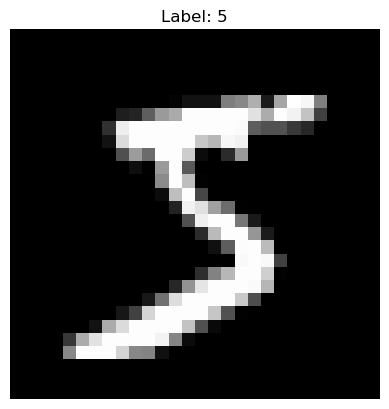

In [7]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

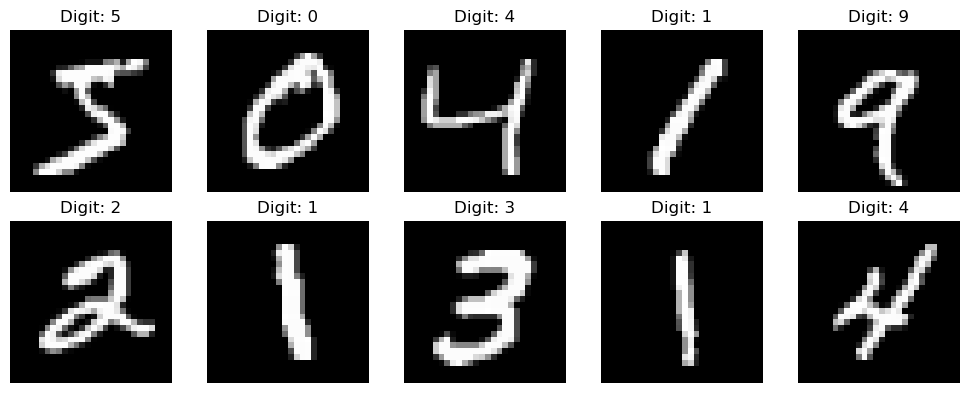

In [8]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [12]:
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

In [13]:
print(y_train[:20])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]


In [14]:
model = keras.Sequential([
    
    keras.layers.Input(shape=(784,)),
    
    keras.layers.Dense(128, activation="relu"),
    
    keras.layers.Dense(64, activation="relu"),
    
    keras.layers.Dense(10, activation="softmax")
    
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9246 - loss: 0.2605 - val_accuracy: 0.9623 - val_loss: 0.1192
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9661 - loss: 0.1099 - val_accuracy: 0.9727 - val_loss: 0.0934
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9765 - loss: 0.0767 - val_accuracy: 0.9702 - val_loss: 0.0939
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9813 - loss: 0.0583 - val_accuracy: 0.9777 - val_loss: 0.0772
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9856 - loss: 0.0436 - val_accuracy: 0.9802 - val_loss: 0.0821
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9878 - loss: 0.0364 - val_accuracy: 0.9795 - val_loss: 0.0827
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9904 - loss: 0.0293 - val_accuracy: 0.9767 - val_loss: 0.0949
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9920 - loss: 0

In [18]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


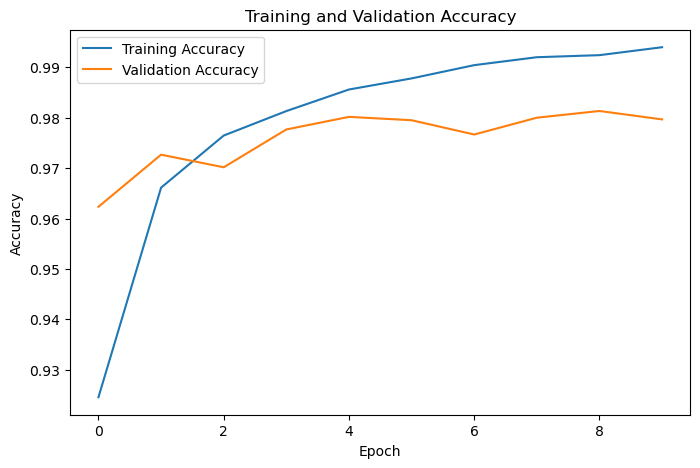

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

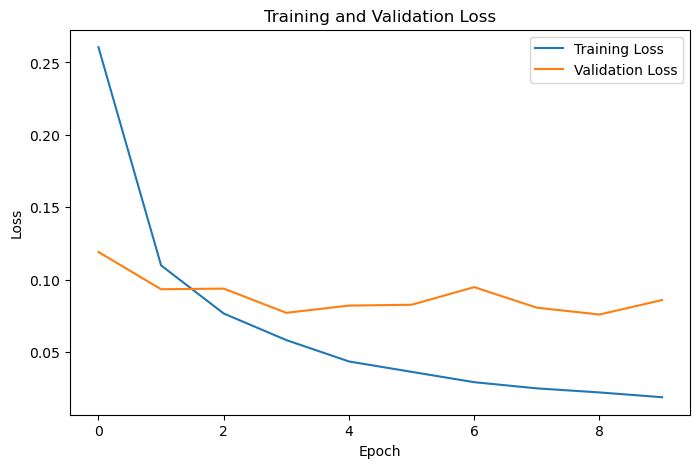

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9794 - loss: 0.0842


In [22]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.08423689752817154
Test Accuracy: 0.9793999791145325


In [23]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [24]:
y_pred = np.argmax(predictions, axis=1)

In [25]:
index = 0

prediction = model.predict(X_test[index].reshape(1, 784))

predicted_digit = np.argmax(prediction)

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted digit: 7
Actual digit: 7


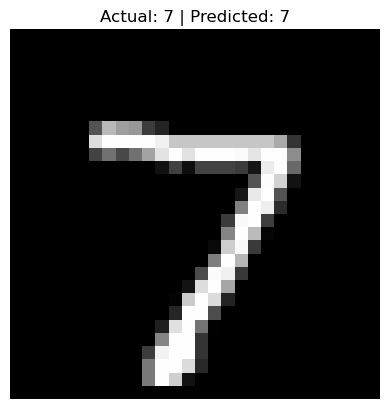

In [26]:
index = 0

plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
plt.title(
    f"Actual: {y_test[index]} | Predicted: {y_pred[index]}"
)
plt.axis("off")
plt.show()

In [27]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 967    0    3    1    1    2    1    1    3    1]
 [   0 1127    0    1    0    0    2    1    4    0]
 [   3    2 1009    4    2    0    3    5    4    0]
 [   0    1    3  994    0    5    0    2    5    0]
 [   2    0    5    0  959    0    4    3    2    7]
 [   2    0    1    9    1  863    5    0    6    5]
 [   9    2    2    0    4    3  936    0    2    0]
 [   0    3    5    3    0    0    0 1011    4    2]
 [   2    1    2    5    2    1    1    4  953    3]
 [   2    3    0    6    8    4    0    9    2  975]]


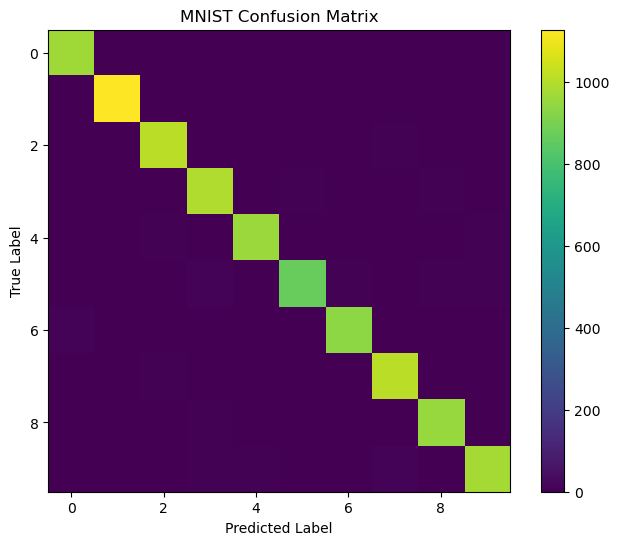

In [28]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")

plt.colorbar()

plt.show()

In [29]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [30]:
wrong_indices = np.where(y_pred != y_test)[0]

print("Number of wrong predictions:", len(wrong_indices))

Number of wrong predictions: 206


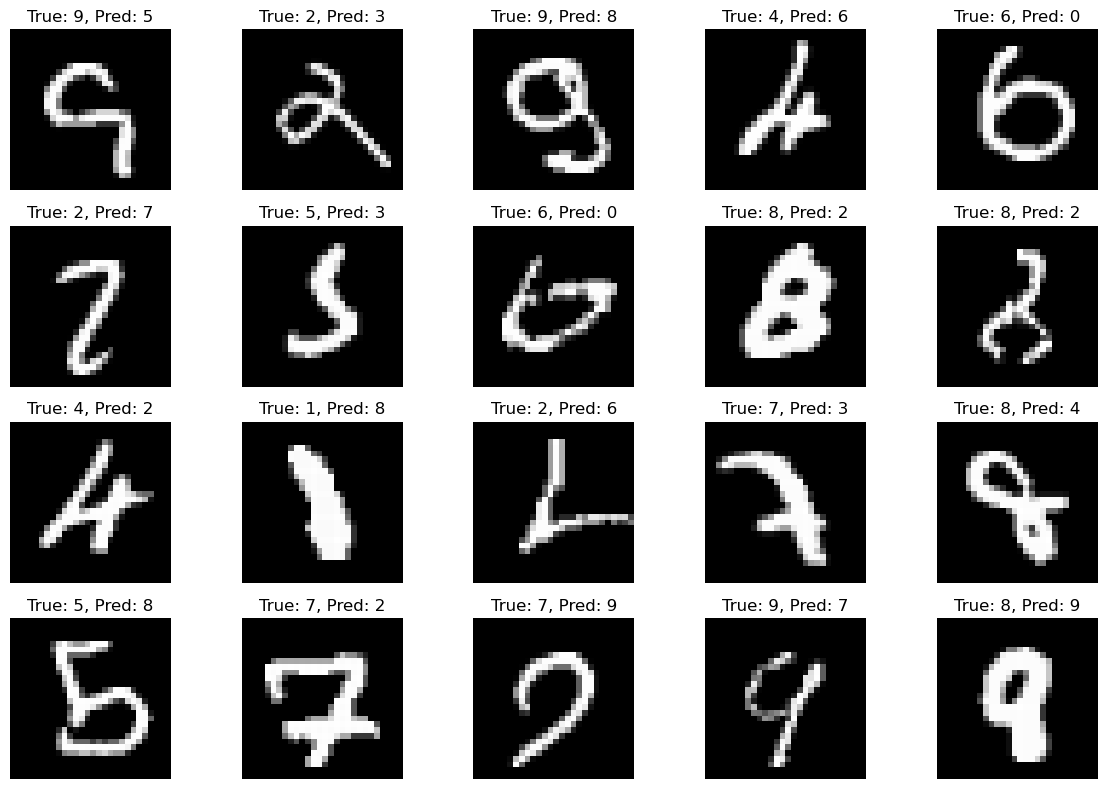

In [31]:
plt.figure(figsize=(12, 8))

for i in range(20):
    
    index = wrong_indices[i]
    
    plt.subplot(4, 5, i + 1)
    
    plt.imshow(
        X_test[index].reshape(28, 28),
        cmap="gray"
    )
    
    plt.title(
        f"True: {y_test[index]}, Pred: {y_pred[index]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
model.save("mnist_dnn.keras")

In [33]:
loaded_model = keras.models.load_model("mnist_dnn.keras")

In [34]:
loss, accuracy = loaded_model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9794 - loss: 0.0842
Test Accuracy: 0.9793999791145325
